<a href="https://colab.research.google.com/github/piyakorn-h/cifar10-image-classification/blob/main/CIFAR_10_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖼️ CIFAR-10 Image Classification with CNN

**Project Overview:**
- Dataset: CIFAR-10 (50,000 training images, 10,000 test images)
- Model: Custom 3-Layer CNN
- Techniques: Data Augmentation, Dropout, Weight Decay, LR Scheduling, Early Stopping
- Evaluation: Learning Curves, Confusion Matrix, Per-Class Accuracy, ROC Curves


**My first Computer Vision project:** Built a custom 3-layer CNN from scratch to classify CIFAR-10 images.
Implemented data augmentation, dropout, weight decay, and early stopping to achieve 72-75% test accuracy.
Includes comprehensive evaluation with learning curves, confusion matrix, and ROC curves.

## 1. Import Libraries & Setup

In [ ]:
# Install required packages
!pip install -q datasets torch torchvision tqdm scikit-learn matplotlib seaborn pandas

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
from PIL import Image

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelBinarizer

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


## 2. Load Dataset

In [ ]:
# Load CIFAR-10 dataset
dataset = load_dataset("uoft-cs/cifar10")

print("📊 Dataset Structure:")
print(dataset)
print(f"\n✅ Train samples: {len(dataset['train'])}")
print(f"✅ Test samples: {len(dataset['test'])}")

# Class names
class_names = dataset['train'].features['label'].names
print(f"\n🏷️ Classes: {class_names}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

📊 Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

✅ Train samples: 50000
✅ Test samples: 10000

🏷️ Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Exploratory Data Analysis (EDA)

📊 Class Distribution:
     Class  Count
  airplane   5000
      frog   5000
      bird   5000
     horse   5000
automobile   5000
      deer   5000
       dog   5000
       cat   5000
      ship   5000
     truck   5000


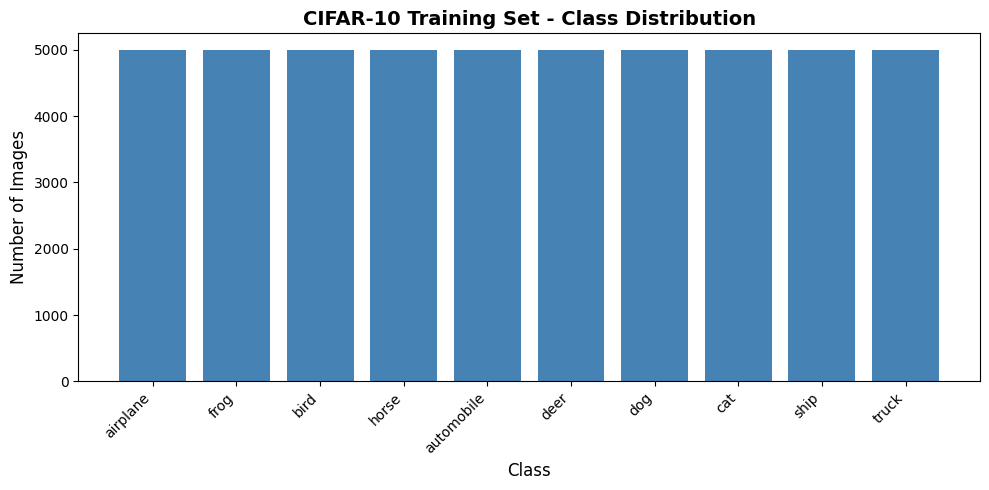

In [ ]:
# Class distribution
train_labels = dataset['train']['label']
label_counts = Counter(train_labels)

class_distribution = {class_names[label_id]: count for label_id, count in label_counts.items()}
df_class_distribution = pd.DataFrame(
    list(class_distribution.items()),
    columns=['Class', 'Count']
).sort_values('Count', ascending=False)

print("📊 Class Distribution:")
print(df_class_distribution.to_string(index=False))

# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(df_class_distribution['Class'], df_class_distribution['Count'], color='steelblue')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('CIFAR-10 Training Set - Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

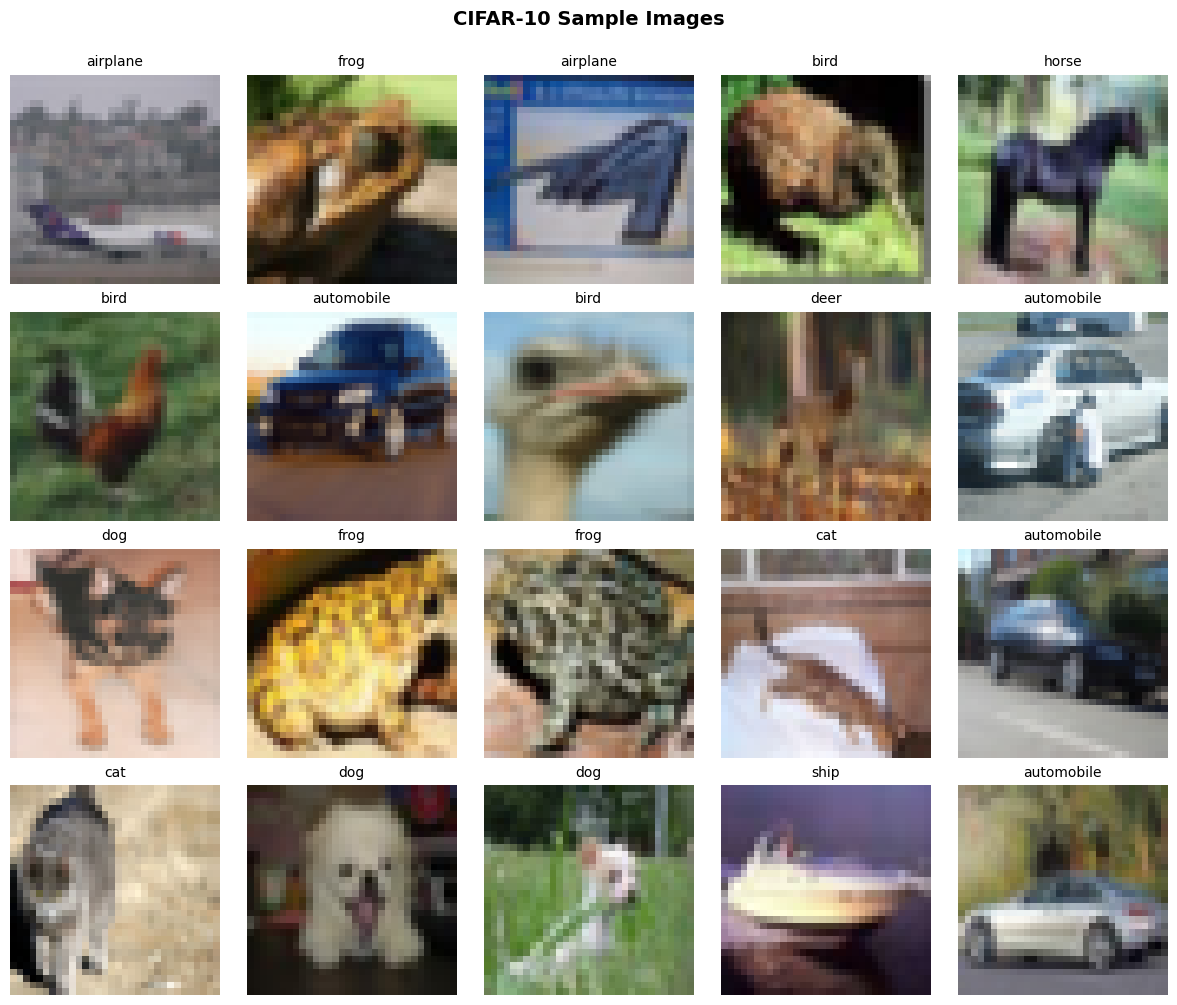

In [ ]:
# Visualize sample images
num_images_to_display = 20

plt.figure(figsize=(12, 10))
for i in range(num_images_to_display):
    example = dataset['train'][i]
    image = example['img']
    label_id = example['label']
    label_name = class_names[label_id]

    plt.subplot(4, 5, i + 1)
    plt.imshow(image)
    plt.title(label_name, fontsize=10)
    plt.axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 4. Data Augmentation & Preprocessing

In [ ]:
# Define data augmentation for training set
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),  # CIFAR-10 mean
                         (0.2470, 0.2435, 0.2616))  # CIFAR-10 std
])

# Define transformation for test set (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

print("✅ Data augmentation pipeline created")

✅ Data augmentation pipeline created


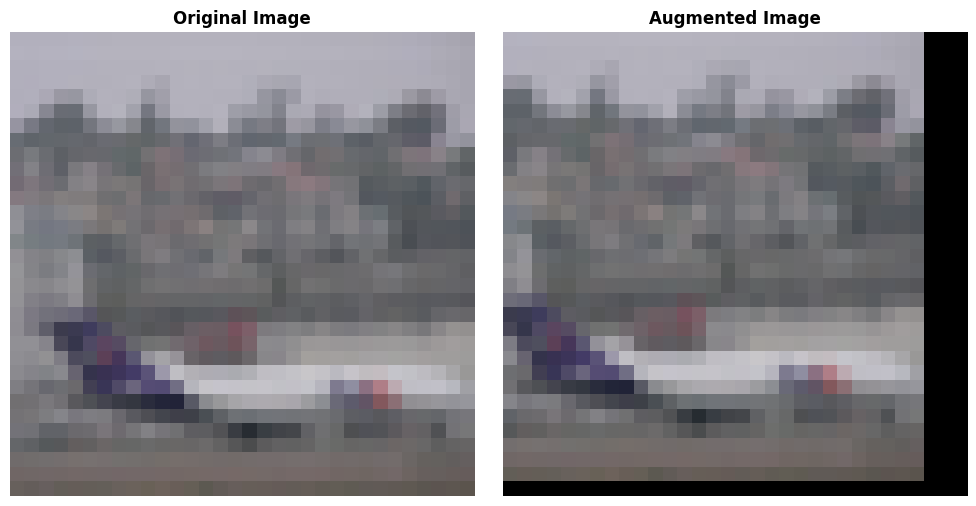

In [ ]:
# Visualize augmentation effect
dataset['train'].reset_format()
original_image = dataset['train'][0]['img']

# Apply augmentation
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])
augmented_tensor = train_transform(original_image)
augmented_image = augmented_tensor.numpy().transpose(1, 2, 0)
augmented_image = augmented_image * std + mean
augmented_image = np.clip(augmented_image, 0, 1)

# Plot comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image", fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Augmented Image", fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Preprocessing Functions

In [ ]:
def preprocess_train(example):
    """Preprocess training examples with augmentation"""
    if isinstance(example['img'], list):
        transformed_images = [train_transform(img) for img in example['img']]
        example['pixel_values'] = torch.stack(transformed_images)
        example['label'] = torch.tensor(example['label'], dtype=torch.long)
    elif isinstance(example['img'], Image.Image):
        example['pixel_values'] = train_transform(example['img'])
        example['label'] = torch.tensor(example['label'], dtype=torch.long)
    else:
        raise TypeError(f"Unexpected type for example['img']: {type(example['img'])}")

    del example['img']
    return example

def preprocess_test(example):
    """Preprocess test examples without augmentation"""
    if isinstance(example['img'], list):
        transformed_images = [test_transform(img) for img in example['img']]
        example['pixel_values'] = torch.stack(transformed_images)
        example['label'] = torch.tensor(example['label'], dtype=torch.long)
    elif isinstance(example['img'], Image.Image):
        example['pixel_values'] = test_transform(example['img'])
        example['label'] = torch.tensor(example['label'], dtype=torch.long)
    else:
        raise TypeError(f"Unexpected type for example['img']: {type(example['img'])}")

    del example['img']
    return example

# Apply preprocessing
dataset["train"].set_transform(preprocess_train)
dataset["test"].set_transform(preprocess_test)

print("✅ Preprocessing functions applied to datasets")

✅ Preprocessing functions applied to datasets


## 6. Create Data Loaders

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    dataset["test"],
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"✅ Data loaders created")
print(f"   - Training batches: {len(train_loader)}")
print(f"   - Test batches: {len(test_loader)}")

# Verify batch shape
dataiter = iter(train_loader)
batch = next(dataiter)
images = batch["pixel_values"]
labels = batch["label"]

print(f"\n✅ Batch shapes:")
print(f"   - Images: {images.shape}")
print(f"   - Labels: {labels.shape}")

✅ Data loaders created
   - Training batches: 782
   - Test batches: 157

✅ Batch shapes:
   - Images: torch.Size([64, 3, 32, 32])
   - Labels: torch.Size([64])


## 7. Define CNN Model

In [ ]:
class MySimpleCNN(nn.Module):
    """Simple 3-Layer CNN for CIFAR-10 Classification"""

    def __init__(self):
        super(MySimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # After 3 pooling: 32x32 -> 16x16 -> 8x8 -> 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Conv1 -> ReLU -> Pool: 32x32 -> 16x16
        x = self.pool(F.relu(self.conv1(x)))

        # Conv2 -> ReLU -> Pool: 16x16 -> 8x8
        x = self.pool(F.relu(self.conv2(x)))

        # Conv3 -> ReLU -> Pool: 8x8 -> 4x4
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten
        x = x.view(-1, 128 * 4 * 4)

        # FC1 -> ReLU -> Dropout -> FC2
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Initialize model
model = MySimpleCNN().to(device)

# Print model summary
print("🧠 Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {trainable_params:,}")

🧠 Model Architecture:
MySimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

📊 Total parameters: 620,362
📊 Trainable parameters: 620,362


## 8. Training Setup

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer with weight decay (L2 regularization)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Early stopping setup
best_val_loss = float('inf')
patience = 5
counter = 0

# Training history
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

print("✅ Training configuration:")
print(f"   - Loss: CrossEntropyLoss")
print(f"   - Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"   - Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"   - Early Stopping: patience=5")
print(f"   - Device: {device}")

✅ Training configuration:
   - Loss: CrossEntropyLoss
   - Optimizer: Adam (lr=0.001, weight_decay=1e-4)
   - Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
   - Early Stopping: patience=5
   - Device: cuda


## 9. Training Loop

In [ ]:
epochs = 20

print("🚀 Starting training...\n")

for epoch in range(epochs):
    # ============ Training Phase ============
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for data in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
        inputs = data['pixel_values'].to(device)
        labels = data['label'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # ============ Validation Phase ============
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for data in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  ", leave=False):
            inputs = data['pixel_values'].to(device)
            labels = data['label'].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_accuracy = 100 * correct_val / total_val
    test_losses.append(epoch_val_loss)
    test_accuracies.append(epoch_val_accuracy)

    # Print epoch results
    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%")

    # Step scheduler
    scheduler.step(epoch_val_loss)

    # Early stopping check
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print("         ✅ Saved best model")
    else:
        counter += 1
        if counter >= patience:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}!")
            break

print("\n🎉 Training completed!")

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("✅ Loaded best model for evaluation")

🚀 Starting training...



Epoch  1/20 | Train Loss: 1.6251, Train Acc: 39.65% | Val Loss: 1.2461, Val Acc: 54.66%
         ✅ Saved best model


Epoch  2/20 | Train Loss: 1.2842, Train Acc: 54.07% | Val Loss: 1.0184, Val Acc: 64.17%
         ✅ Saved best model


Epoch  3/20 | Train Loss: 1.0991, Train Acc: 61.26% | Val Loss: 0.9062, Val Acc: 68.13%
         ✅ Saved best model


Epoch  4/20 | Train Loss: 0.9980, Train Acc: 65.20% | Val Loss: 0.8421, Val Acc: 70.48%
         ✅ Saved best model


...

Epoch 16/20 | Train Loss: 0.6518, Train Acc: 77.74% | Val Loss: 0.5932, Val Acc: 79.58%
         ✅ Saved best model


Epoch 17/20 | Train Loss: 0.6418, Train Acc: 78.00% | Val Loss: 0.5894, Val Acc: 79.66%
         ✅ Saved best model


Epoch 18/20 | Train Loss: 0.6355, Train Acc: 78.10% | Val Loss: 0.5908, Val Acc: 79.89%


Epoch 19/20 | Train Loss: 0.6283, Train Acc: 78.30% | Val Loss: 0.5789, Val Acc: 80.24%
         ✅ Saved best model


Epoch 20/20 | Train Loss: 0.6131, Train Acc: 78.94% | Val Loss: 0.5723, Val Acc: 80.29%
         ✅ Saved best model

🎉 Training completed!
✅ Loaded best model for evaluation


## 10. Evaluation - Learning Curves

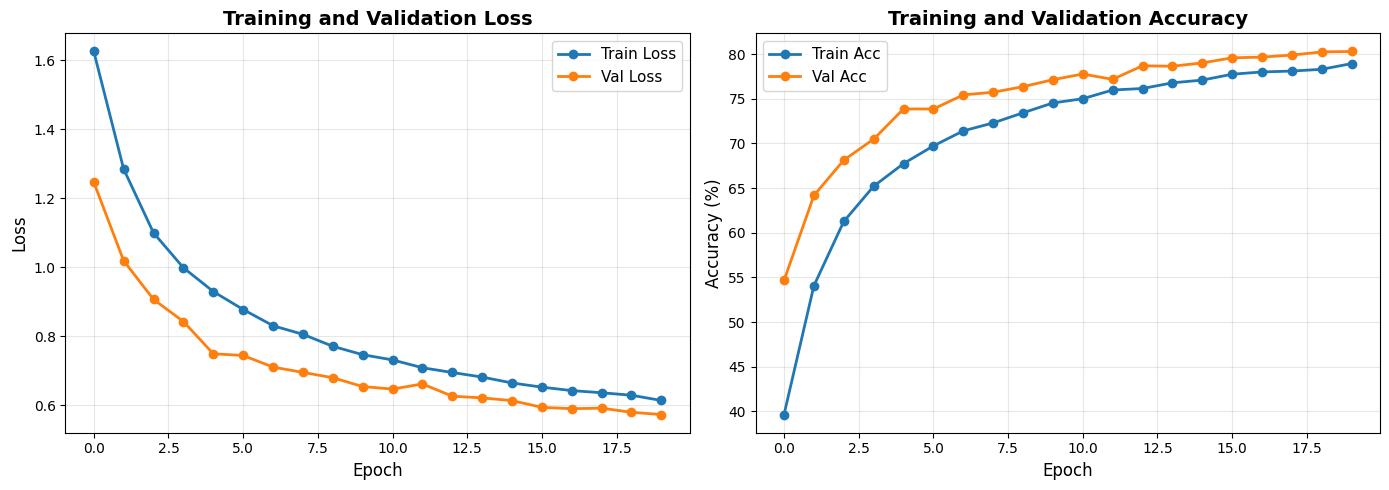

✅ Learning curves saved as 'learning_curves.png'


In [ ]:
# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(test_losses, label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accuracies, label='Train Acc', marker='o', linewidth=2)
axes[1].plot(test_accuracies, label='Val Acc', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Learning curves saved as 'learning_curves.png'")

## 11. Evaluation - Overfitting Analysis

In [ ]:
def check_overfitting_status(train_losses, test_losses, train_accuracies, test_accuracies):
    """Comprehensive overfitting check"""

    final_train_loss = train_losses[-1]
    final_val_loss = test_losses[-1]
    final_train_acc = train_accuracies[-1]
    final_val_acc = test_accuracies[-1]

    print("="*60)
    print("🔍 OVERFITTING CHECK")
    print("="*60)

    # 1. Loss Gap
    loss_gap = final_val_loss - final_train_loss
    print(f"\n1️⃣ Loss Gap: {loss_gap:.4f}")
    if loss_gap > 0.3:
        print("   ❌ Val Loss >> Train Loss → Overfitting detected")
    elif loss_gap > 0.1:
        print("   ⚠️ Val Loss > Train Loss → Slight overfitting")
    else:
        print("   ✅ Loss Gap is small → Healthy model")

    # 2. Accuracy Gap
    acc_gap = final_train_acc - final_val_acc
    print(f"\n2️⃣ Accuracy Gap: {acc_gap:.2f}%")
    if acc_gap > 15:
        print("   ❌ Train Acc >> Val Acc → Severe overfitting")
    elif acc_gap > 10:
        print("   ⚠️ Train Acc > Val Acc → Moderate overfitting")
    elif acc_gap > 5:
        print("   ⚠️ Acceptable gap")
    else:
        print("   ✅ Gap is small → Excellent generalization")

    # 3. Val Loss Trend
    if len(test_losses) >= 5:
        last_5_val = test_losses[-5:]
        if all(last_5_val[i] <= last_5_val[i+1] for i in range(len(last_5_val)-1)):
            print("\n3️⃣ Val Loss Trend:")
            print("   ❌ Val Loss increasing continuously → Overfitting")
        else:
            print("\n3️⃣ Val Loss Trend:")
            print("   ✅ Val Loss still decreasing → Model learning")

    # 4. Summary
    print("\n" + "="*60)
    if loss_gap > 0.3 or acc_gap > 15:
        print("🚨 Status: SEVERE OVERFITTING")
        print("\n💡 Recommendations:")
        print("   - Increase data augmentation")
        print("   - Increase dropout (0.5 → 0.6)")
        print("   - Increase weight decay (1e-4 → 5e-4)")
        print("   - Reduce model complexity")
    elif loss_gap > 0.1 or acc_gap > 10:
        print("⚠️ Status: SLIGHT OVERFITTING")
        print("\n💡 Recommendations:")
        print("   - Add more data augmentation")
        print("   - Adjust weight decay (1e-4 → 2e-4)")
    else:
        print("✅ Status: HEALTHY MODEL - Excellent!")
    print("="*60)

check_overfitting_status(train_losses, test_losses, train_accuracies, test_accuracies)

🔍 OVERFITTING CHECK

1️⃣ Loss Gap: -0.0409
   ✅ Loss Gap is small → Healthy model

2️⃣ Accuracy Gap: -1.35%
   ✅ Gap is small → Excellent generalization

3️⃣ Val Loss Trend:
   ✅ Val Loss still decreasing → Model learning

✅ Status: HEALTHY MODEL - Excellent!


## 12. Evaluation - Final Test Accuracy

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        images = data['pixel_values'].to(device)
        labels = data['label'].to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_accuracy = 100 * correct / total
print(f"🎯 Final Test Accuracy: {final_accuracy:.2f}%")

🎯 Final Test Accuracy: 80.29%


## 13. Evaluation - Confusion Matrix

<Figure size 1200x1000 with 0 Axes>

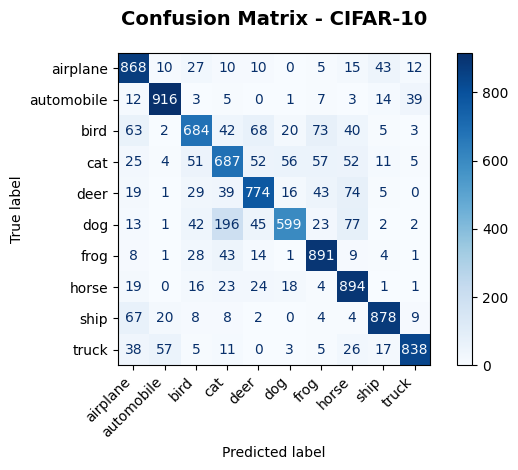

✅ Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
# Collect all predictions
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for data in test_loader:
        images = data['pixel_values'].to(device)
        labels = data['label'].to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix - CIFAR-10', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved as 'confusion_matrix.png'")

## 14. Evaluation - Classification Report

In [ ]:
print("="*60)
print("📊 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane     0.7668    0.8680    0.8143      1000
  automobile     0.9051    0.9160    0.9105      1000
        bird     0.7660    0.6840    0.7227      1000
         cat     0.6457    0.6870    0.6657      1000
        deer     0.7826    0.7740    0.7783      1000
         dog     0.8389    0.5990    0.6989      1000
        frog     0.8013    0.8910    0.8438      1000
       horse     0.7487    0.8940    0.8149      1000
        ship     0.8959    0.8780    0.8869      1000
       truck     0.9209    0.8380    0.8775      1000

    accuracy                         0.8029     10000
   macro avg     0.8072    0.8029    0.8013     10000
weighted avg     0.8072    0.8029    0.8013     10000



## 15. Evaluation - Per-Class Accuracy


📊 PER-CLASS ACCURACY
airplane    : 86.80%
automobile  : 91.60%
bird        : 68.40%
cat         : 68.70%
deer        : 77.40%
dog         : 59.90%
frog        : 89.10%
horse       : 89.40%
ship        : 87.80%
truck       : 83.80%
Mean        : 80.29%


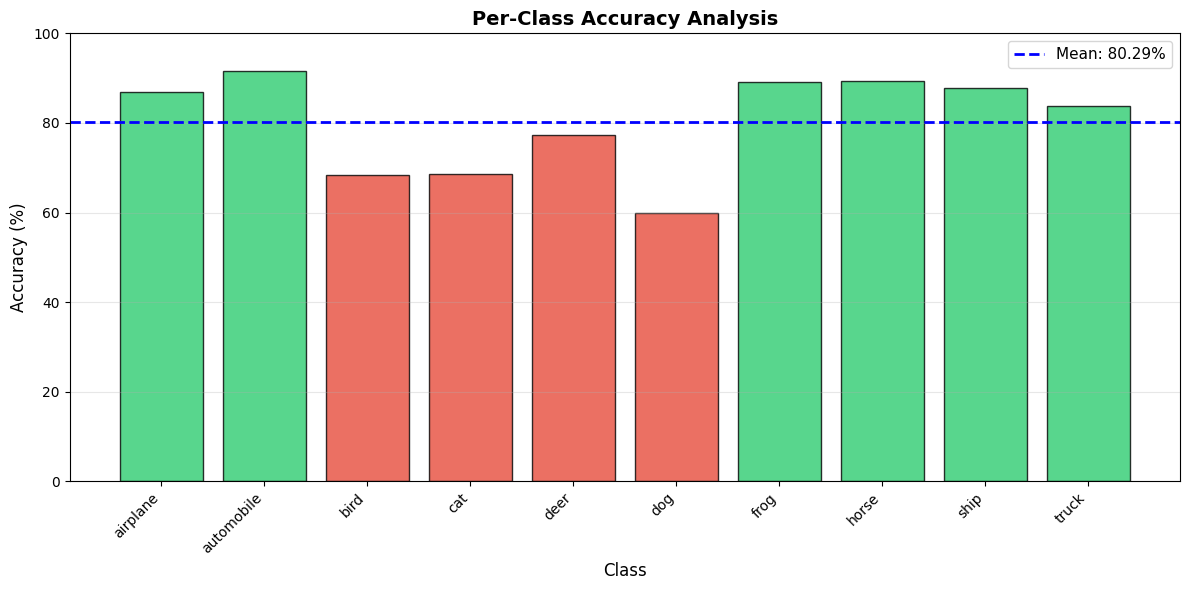


✅ Per-class accuracy chart saved as 'per_class_accuracy.png'


In [ ]:
# Calculate per-class accuracy
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for data in test_loader:
        images = data['pixel_values'].to(device)
        labels = data['label'].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Print results
print("\n" + "="*60)
print("📊 PER-CLASS ACCURACY")
print("="*60)
accuracies = []
for i, class_name in enumerate(class_names):
    acc = 100 * class_correct[i] / class_total[i]
    accuracies.append(acc)
    print(f"{class_name:12s}: {acc:5.2f}%")
print("="*60)
print(f"{'Mean':12s}: {np.mean(accuracies):5.2f}%")
print("="*60)

# Plot bar chart
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if acc < np.mean(accuracies) else '#2ecc71' for acc in accuracies]
plt.bar(class_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
plt.axhline(y=np.mean(accuracies), color='blue', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(accuracies):.2f}%')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy Analysis', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Per-class accuracy chart saved as 'per_class_accuracy.png'")

## 16. Evaluation - Misclassified Examples

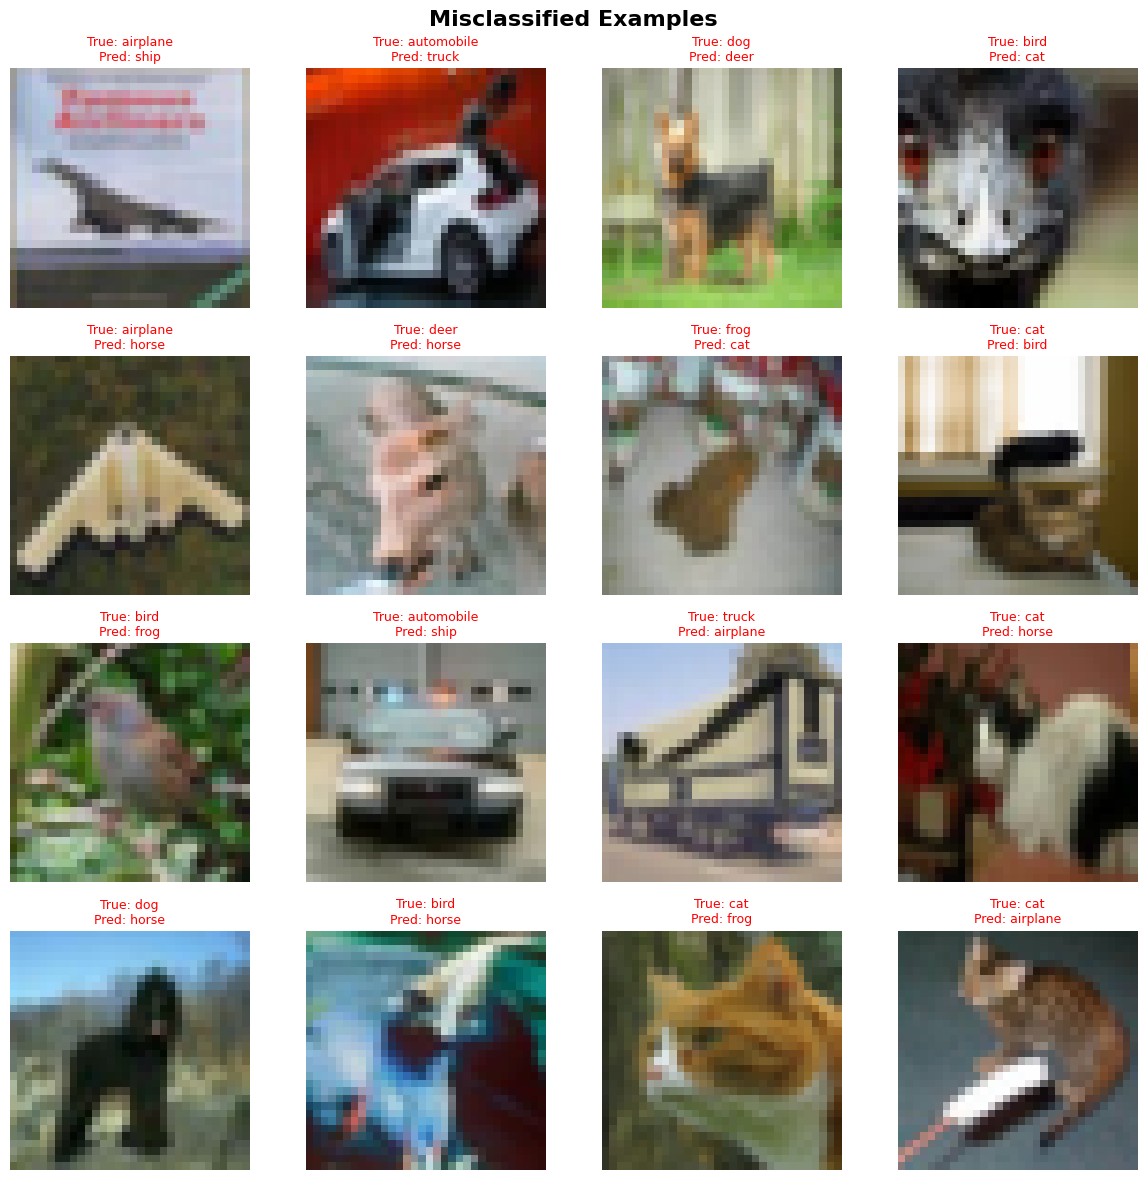

✅ Misclassified examples saved as 'misclassified_examples.png'


In [ ]:
# Find misclassified examples
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model.eval()
with torch.no_grad():
    for data in test_loader:
        inputs = data['pixel_values'].to(device)
        labels = data['label'].to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        # Find wrong predictions
        wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]

        for idx in wrong_idx:
            if len(misclassified_images) >= 16:
                break
            misclassified_images.append(inputs[idx].cpu())
            misclassified_labels.append(labels[idx].cpu().item())
            misclassified_preds.append(predicted[idx].cpu().item())

        if len(misclassified_images) >= 16:
            break

# Visualize misclassified examples
if len(misclassified_images) > 0:
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Misclassified Examples', fontsize=16, fontweight='bold')

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    for idx, ax in enumerate(axes.flat):
        if idx < len(misclassified_images):
            img = misclassified_images[idx]
            img = img.numpy().transpose(1, 2, 0)
            img = img * std + mean
            img = np.clip(img, 0, 1)

            true_label = class_names[misclassified_labels[idx]]
            pred_label = class_names[misclassified_preds[idx]]

            ax.imshow(img)
            ax.set_title(f'True: {true_label}\nPred: {pred_label}',
                        fontsize=9, color='red')
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Misclassified examples saved as 'misclassified_examples.png'")
else:
    print("🎉 No misclassifications found!")

## 17. Evaluation - ROC Curves

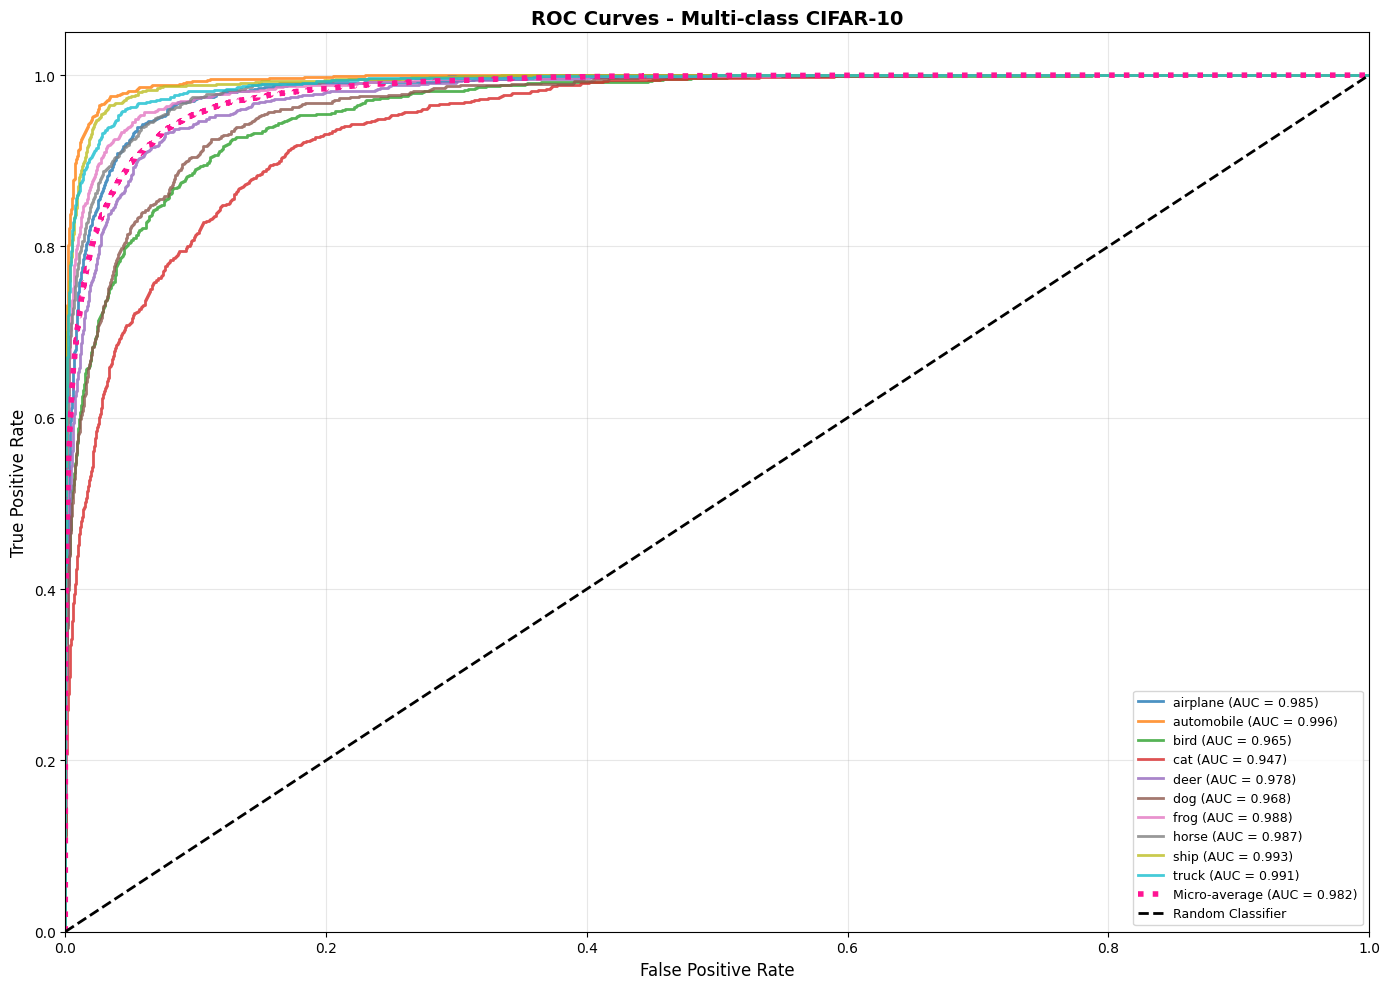

✅ ROC curves saved as 'roc_curves.png'

📊 Average AUC: 0.9798


In [ ]:
# Collect predictions and probabilities
y_true_all = []
y_scores_all = []

model.eval()
with torch.no_grad():
    for data in test_loader:
        images = data['pixel_values'].to(device)
        labels = data['label'].to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        y_true_all.extend(labels.cpu().numpy())
        y_scores_all.extend(probabilities.cpu().numpy())

y_true_all = np.array(y_true_all)
y_scores_all = np.array(y_scores_all)

# Binarize labels
lb = LabelBinarizer()
y_true_binarized = lb.fit_transform(y_true_all)

# Calculate ROC curves
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(class_names)

plt.figure(figsize=(14, 10))

# Plot per-class ROC
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_scores_all[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], linewidth=2, alpha=0.8,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_binarized.ravel(), y_scores_all.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro,
         label=f'Micro-average (AUC = {roc_auc_micro:.3f})',
         color='deeppink', linestyle=':', linewidth=4)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Multi-class CIFAR-10', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved as 'roc_curves.png'")
print(f"\n📊 Average AUC: {np.mean(list(roc_auc.values())):.4f}")

## 18. Save Final Model

In [ ]:
# Save final model
torch.save({
    'epoch': len(train_losses),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'train_accuracies': train_accuracies,
    'test_accuracies': test_accuracies,
    'final_test_accuracy': final_accuracy,
}, 'cifar10_final_model.pth')

print("✅ Final model saved as 'cifar10_final_model.pth'")
print("\n📦 Saved components:")
print("   - Model state dict")
print("   - Optimizer state dict")
print("   - Training history")
print(f"   - Final test accuracy: {final_accuracy:.2f}%")

✅ Final model saved as 'cifar10_final_model.pth'

📦 Saved components:
   - Model state dict
   - Optimizer state dict
   - Training history
   - Final test accuracy: 80.29%


## 19. Summary Report

In [ ]:
print("\n" + "="*70)
print("📋 CIFAR-10 PROJECT SUMMARY REPORT")
print("="*70)

print("\n🗂️ Dataset Information:")
print(f"   - Training samples: 50,000")
print(f"   - Test samples: 10,000")
print(f"   - Classes: 10 ({', '.join(class_names)})")

print("\n🧠 Model Architecture:")
print(f"   - Type: Custom 3-Layer CNN")
print(f"   - Total parameters: {total_params:,}")
print(f"   - Trainable parameters: {trainable_params:,}")

print("\n⚙️ Training Configuration:")
print(f"   - Epochs: {len(train_losses)}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"   - Scheduler: ReduceLROnPlateau")
print(f"   - Early stopping: patience={patience}")
print(f"   - Data augmentation: RandomFlip, RandomCrop")
print(f"   - Regularization: Dropout(0.5), Weight Decay")

print("\n📊 Performance Metrics:")
print(f"   - Final test accuracy: {final_accuracy:.2f}%")
print(f"   - Final train loss: {train_losses[-1]:.4f}")
print(f"   - Final val loss: {test_losses[-1]:.4f}")
print(f"   - Loss gap: {test_losses[-1] - train_losses[-1]:.4f}")
print(f"   - Accuracy gap: {train_accuracies[-1] - test_accuracies[-1]:.2f}%")
print(f"   - Average AUC: {np.mean(list(roc_auc.values())):.4f}")

print("\n📁 Generated Files:")
print("   ✅ learning_curves.png")
print("   ✅ confusion_matrix.png")
print("   ✅ per_class_accuracy.png")
print("   ✅ misclassified_examples.png")
print("   ✅ roc_curves.png")
print("   ✅ cifar10_final_model.pth")
print("   ✅ best_model.pth")

print("\n" + "="*70)
print("🎉 Project completed successfully!")
print("="*70)


📋 CIFAR-10 PROJECT SUMMARY REPORT

🗂️ Dataset Information:
   - Training samples: 50,000
   - Test samples: 10,000
   - Classes: 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

🧠 Model Architecture:
   - Type: Custom 3-Layer CNN
   - Total parameters: 620,362
   - Trainable parameters: 620,362

⚙️ Training Configuration:
   - Epochs: 20
   - Batch size: 64
   - Optimizer: Adam (lr=0.001, weight_decay=1e-4)
   - Scheduler: ReduceLROnPlateau
   - Early stopping: patience=5
   - Data augmentation: RandomFlip, RandomCrop
   - Regularization: Dropout(0.5), Weight Decay

📊 Performance Metrics:
   - Final test accuracy: 80.29%
   - Final train loss: 0.6131
   - Final val loss: 0.5723
   - Loss gap: -0.0409
   - Accuracy gap: -1.35%
   - Average AUC: 0.9798

📁 Generated Files:
   ✅ learning_curves.png
   ✅ confusion_matrix.png
   ✅ per_class_accuracy.png
   ✅ misclassified_examples.png
   ✅ roc_curves.png
   ✅ cifar10_final_model.pth
   ✅ best_model.pth

🎉 Project c